# Hafta 4 · Ders 7 — Ortogonallik ve Gram–Schmidt

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Geçen hafta bir problemle bitti: normal denklemler koşul sayısının karesini alır ve kararsız hâle gelir.
Çare **ortogonalliktir**. Baz vektörleri karşılıklı dik ve birim uzunlukta olduğunda — bir
**ortonormal baz** — izdüşüm basit bir nokta çarpımına dönüşür, matris tersine çevirmeye gerek kalmaz
ve sayısal hatalar birikmeyi bırakır.

Bu defter, **Gram–Schmidt sürecini** inşa eder: herhangi bir bağımsız vektör kümesini alıp onları
bir ortonormal baza düzleştiren bir tarif. Ayrıca onun kararsızlığıyla ve onu düzelten **değiştirilmiş**
sürümle tanışacağız — doğrudan bir sonraki dersteki QR ayrışımını hazırlayarak.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import plot_vectors_2d, check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Ortonormal bazlar neden harikadır

Genel bir bazda, bir vektörün koordinatlarını bulmak, bir lineer sistem çözmek demektir. Bir
**ortonormal** bazda $\{\mathbf{q}_1,\dots,\mathbf{q}_n\}$ (karşılıklı dik, her biri 1 uzunlukta),
$\mathbf{q}_i$ boyunca koordinat *yalnızca bir nokta çarpımıdır*:

$$ \mathbf{v} = \sum_i (\mathbf{v}\cdot\mathbf{q}_i)\,\mathbf{q}_i $$

Çözülecek sistem yok. Ve sütunları $\mathbf{q}_i$ olan $Q$ matrisi $Q^\top Q = I$ koşulunu sağlar,
bu yüzden onu "tersine çevirmek" bedavadır: $Q^{-1} = Q^\top$. Bu, en küçük kareleri kurtaran özelliktir.

In [2]:
# bir ortonormal çift
q1 = np.array([1.0, 0.0])
q2 = np.array([0.0, 1.0])
v = np.array([3.0, 4.0])

coords = np.array([v @ q1, v @ q2])          # koordinatlar = nokta çarpımları
print("{q1, q2}'de v'nin koordinatları:", coords)
print("yeniden inşa:", coords[0]*q1 + coords[1]*q2)

Q = np.column_stack([q1, q2])
check("Qᵀ Q == I", Q.T @ Q, np.eye(2))

coordinates of v in {q1, q2}: [3. 4.]
reconstruction: [3. 4.]
[PASS] Qᵀ Q == I                        max|Δ| = 0.00e+00


True

## 2. Gram–Schmidt: ortonormallik üretmek

Bağımsız vektörler $\mathbf{a}_1, \mathbf{a}_2, \dots$ verildiğinde, Gram–Schmidt her seferinde bir
vektör ekleyerek bir ortonormal küme inşa eder. Fikir, saf Ders-2 izdüşümüdür:

1. $\mathbf{a}_k$'yi al.
2. Zaten ortonormalleştirilmiş her şeye olan izdüşümünü **çıkar** — bu, zaten kapsadığımız
   yönlerdeki tüm bileşenleri kaldırır.
3. Geriye kalanı **normalleştir**.

$$ \mathbf{u}_k = \mathbf{a}_k - \sum_{j<k} (\mathbf{a}_k\cdot\mathbf{q}_j)\,\mathbf{q}_j, \qquad \mathbf{q}_k = \frac{\mathbf{u}_k}{\lVert \mathbf{u}_k\rVert} $$

In [3]:
def gram_schmidt(A):
    A = np.asarray(A, float)
    n_vectors = A.shape[1]
    Q = np.zeros_like(A)
    for k in range(n_vectors):
        v = A[:, k].copy()
        for j in range(k):                       # önceki q'lara olan izdüşümleri çıkar
            v -= (A[:, k] @ Q[:, j]) * Q[:, j]
        Q[:, k] = v / np.linalg.norm(v)          # normalleştir
    return Q

A = np.array([[1.0, 1.0],
              [1.0, 0.0],
              [0.0, 1.0]])
Q = gram_schmidt(A)
print("Q =\n", Q)
check("Qᵀ Q == I (ortonormal sütunlar)", Q.T @ Q, np.eye(2), atol=1e-10)

Q =
 [[ 0.7071  0.4082]
 [ 0.7071 -0.4082]
 [ 0.      0.8165]]
[PASS] Qᵀ Q == I (orthonormal columns)  max|Δ| = 2.22e-16


True

### Süreci 2B'de görselleştirmek

İki eğik vektörle başlayın. Gram–Schmidt birincisini tutar (yalnızca normalleştirir), ardından
ikincisini birinciye dik olana kadar büker.

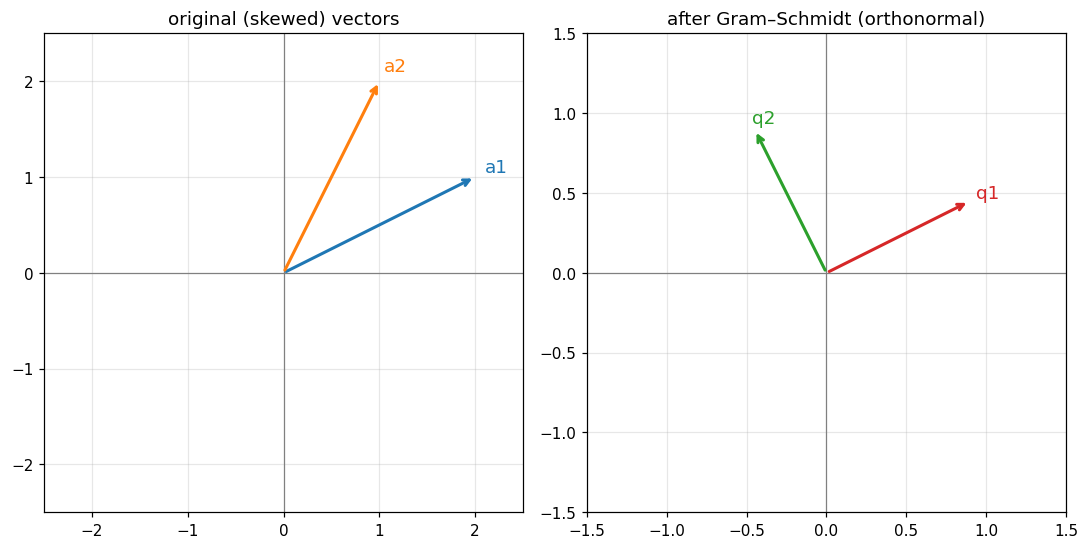

q1 · q2 = 0.0  → perpendicular ✓


In [4]:
a1 = np.array([2.0, 1.0])
a2 = np.array([1.0, 2.0])
A2 = np.column_stack([a1, a2])
Q2 = gram_schmidt(A2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_vectors_2d([a1, a2], colors=["C0", "C1"], labels=["a1", "a2"], ax=axes[0], lim=(-2.5, 2.5))
axes[0].set_title("orijinal (eğik) vektörler")
plot_vectors_2d([Q2[:, 0], Q2[:, 1]], colors=["C3", "C2"],
                labels=["q1", "q2"], ax=axes[1], lim=(-1.5, 1.5))
axes[1].set_title("Gram–Schmidt sonrası (ortonormal)")
plt.tight_layout(); plt.show()

print("q1 · q2 =", round(Q2[:, 0] @ Q2[:, 1], 12), " → dik ✓")

## 3. Klasik Gram–Schmidt sayısal olarak kırılgandır

Yukarıdaki sürüm ("klasik" Gram–Schmidt), vektörler neredeyse paralel olduğunda ortogonalliği kaybeder,
çünkü yuvarlama hataları birikir. **Değiştirilmiş Gram–Schmidt**, her izdüşümü *hemen* çıkaran,
yeniden sıralanmış bir şekilde aynı sonucu hesaplar ve hataları küçük tutar. Fark, güzel verilerde
görünmez ve kötü koşullanmış verilerde çarpıcıdır.

In [5]:
def modified_gram_schmidt(A):
    A = np.asarray(A, float).copy()
    n = A.shape[1]
    Q = np.zeros_like(A)
    for k in range(n):
        v = A[:, k].copy()
        for j in range(k):
            v -= (v @ Q[:, j]) * Q[:, j]         # *güncellenmiş* v'yi kullanarak çıkar
        Q[:, k] = v / np.linalg.norm(v)
    return Q

# kasıtlı olarak kötü koşullanmış, neredeyse-paralel sütunlardan oluşan bir küme
rng = np.random.default_rng(0)
n = 50
base = rng.normal(size=n)
A_ill = np.column_stack([base + 1e-8 * rng.normal(size=n) for _ in range(4)])
A_ill += 1e-3 * rng.normal(size=A_ill.shape)

for name, fn in [("klasik", gram_schmidt), ("değiştirilmiş", modified_gram_schmidt)]:
    Q = fn(A_ill)
    err = np.max(np.abs(Q.T @ Q - np.eye(4)))
    print(f"{name:<14} maks |QᵀQ − I| = {err:.2e}")

classical  max |QᵀQ − I| = 6.47e-11
modified   max |QᵀQ − I| = 1.09e-13


## 4. Bir alt uzaya ortogonal izdüşüm

Bir alt uzay için ortonormal baz $Q$ varken, herhangi bir vektörü o alt uzaya izdüşürmek yalnızca
$QQ^\top \mathbf{v}$'dir — ters yok. Bunu normal denklemlerdeki dağınık $X(X^\top X)^{-1}X^\top$ ile
karşılaştırın: ortogonallik tersi tamamen silmiştir. Bu, bir sonraki derste QR olarak tam olarak
bir araya getirdiğimiz kararlı en küçük karelerin motorudur.

In [6]:
# alt uzay = R^3'te iki ortonormalleştirilmiş vektör tarafından gerilen düzlem
A = np.array([[1.0, 1.0], [1.0, 0.0], [0.0, 1.0]])
Q = gram_schmidt(A)

v = np.array([1.0, 2.0, 3.0])
proj = Q @ (Q.T @ v)              # düzleme ortogonal izdüşüm
resid = v - proj

print("v'nin düzleme izdüşümü :", proj)
print("kalıntı                :", resid)
print("kalıntı ⟂ alt uzay? Qᵀ·kalıntı =", Q.T @ resid, " ≈ 0 ✓")

projection of v onto the plane : [2.3333 0.6667 1.6667]
residual                       : [-1.3333  1.3333  1.3333]
residual ⟂ subspace? Qᵀ·resid = [ 0. -0.]  ≈ 0 ✓


## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer

- **Kararlı en küçük kareler / QR** (sonraki ders), kırılgan normal denklemleri tam olarak bu
  ortonormalleştirmeyi kullanarak değiştirir.
- **Beyazlatma ve korelasyon giderme (decorrelation)**, öznitelikleri ortogonal bir kümeye dönüştürür
  ki hiçbir ikisi gereksiz bilgi taşımasın — standart bir ön işleme adımı.
- **Ortogonal ağırlık başlatma**, sinyal büyüklüklerini derin ağlardan akarken kararlı tutar ve
  kaybolan/patlayan aktivasyonları hafifletir.
- **Ortogonallik cezaları**, çeşitli, gereksiz olmayan temsilleri teşvik etmek için kayıp fonksiyonlarına
  eklenir.

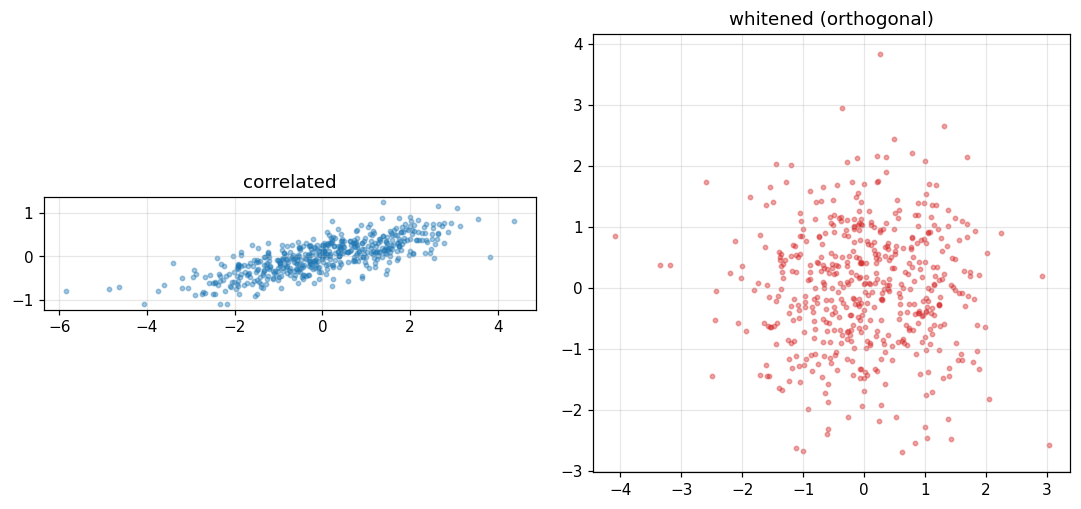

covariance after whitening ≈ identity:
 [[ 1. -0.]
 [-0.  1.]]


In [7]:
# beyazlatma gösterimi: korelasyonlu 2B veriyi ortogonal (korelasyonu giderilmiş) bir buluta çevir
rng = np.random.default_rng(1)
X = rng.normal(size=(500, 2)) @ np.array([[1.0, 0.0], [1.2, 0.4]])   # korelasyonlu
Xc = X - X.mean(0)
cov = (Xc.T @ Xc) / len(Xc)
# kovaryansın simetrik ters karekökünden beyazlatma matrisi
vals, vecs = np.linalg.eigh(cov)
W = vecs @ np.diag(vals ** -0.5) @ vecs.T
Xw = Xc @ W

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(Xc[:, 0], Xc[:, 1], s=8, alpha=0.4, color="C0"); axes[0].set_title("korelasyonlu")
axes[1].scatter(Xw[:, 0], Xw[:, 1], s=8, alpha=0.4, color="C3"); axes[1].set_title("beyazlatılmış (ortogonal)")
for ax in axes:
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("beyazlatmadan sonra kovaryans ≈ birim matris:\n", (Xw.T @ Xw) / len(Xw))

## Alıştırmalar

1. **A'yı Q'dan yeniden inşa et.** Gram–Schmidt'ten gelen $Q$ verildiğinde, kullanılan katsayılar $A = QR$ ile bir üst-üçgensel $R$ oluşturur. $R = Q^\top A$'yı hesaplayın ve $QR = A$'yı doğrulayın. (Bu, QR'nin *kendisidir* — sonraki ders.)
2. **Ortonormal ⇒ uzunluk-koruyan.** $Q$ ile (ortonormal sütunlu) çarpmanın vektör normlarını koruduğunu gösterin: $\lVert Q\mathbf{x}\rVert = \lVert \mathbf{x}\rVert$.
3. **Klasik G–S'yi boz.** Klasik Gram–Schmidt'in ortogonalliği gözle görülür biçimde kaybettiği ama değiştirilmişin kaybetmediği en küçük pertürbasyon ölçeğini bulun.

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. R = Qᵀ A ve A = Q R
A = np.array([[1.0, 1.0], [1.0, 0.0], [0.0, 1.0]])
Q = gram_schmidt(A)
R = Q.T @ A
check("A == Q R", Q @ R, A, atol=1e-10)
print("R (üst-üçgensel) =\n", R)

# 2. norm korunumu
rng = np.random.default_rng(2)
x = rng.normal(size=2)
print("‖x‖   =", round(np.linalg.norm(x), 6))
print("‖Qx‖  =", round(np.linalg.norm(Q @ x), 6), " → eşit ✓")

[PASS] A == Q R                         max|Δ| = 4.44e-16
R (upper-triangular) =
 [[1.4142 0.7071]
 [0.     1.2247]]
‖x‖   = 0.555884
‖Qx‖  = 0.555884  → equal ✓


## Özet ve sırada ne var

Ortonormal bazlar, izdüşümü bir nokta çarpımına ve tersine çevirmeyi bir transpoza dönüştürür.
Gram–Schmidt, herhangi bir bağımsız kümeden böyle bir baz üretir; değiştirilmiş çeşit bunu kararlı
biçimde yapar. Hatta $A = QR$'ye bile rastladık.

**Sırada — `08_qr_ayrisimi.ipynb`:** $A = QR$'yi resmileştiriyor, Householder yansımalarıyla
tanışıyor ve en küçük kareleri $X^\top X$'i *hiç* oluşturmadan çözmek için QR kullanıyoruz — sonunda
Hafta 3'ün kararsızlığını çözerek.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 4 · Ders 7*